In [38]:
import networkx as nx
import matplotlib.pyplot as plt


In [39]:
G = nx.read_edgelist("facebook_combined.txt.gz", create_using=nx.Graph(), nodetype=int)

In [40]:
#louvain
C = nx.community.louvain_communities(G)
print(f"Number of communities: {len(C)}")

Number of communities: 16


In [41]:
community_sizes = [len(c) for c in C]
print(f"Community sizes: {community_sizes}")

Community sizes: [350, 435, 323, 128, 432, 25, 206, 19, 19, 226, 535, 73, 423, 237, 548, 60]


In [42]:
pos = nx.spring_layout(G)


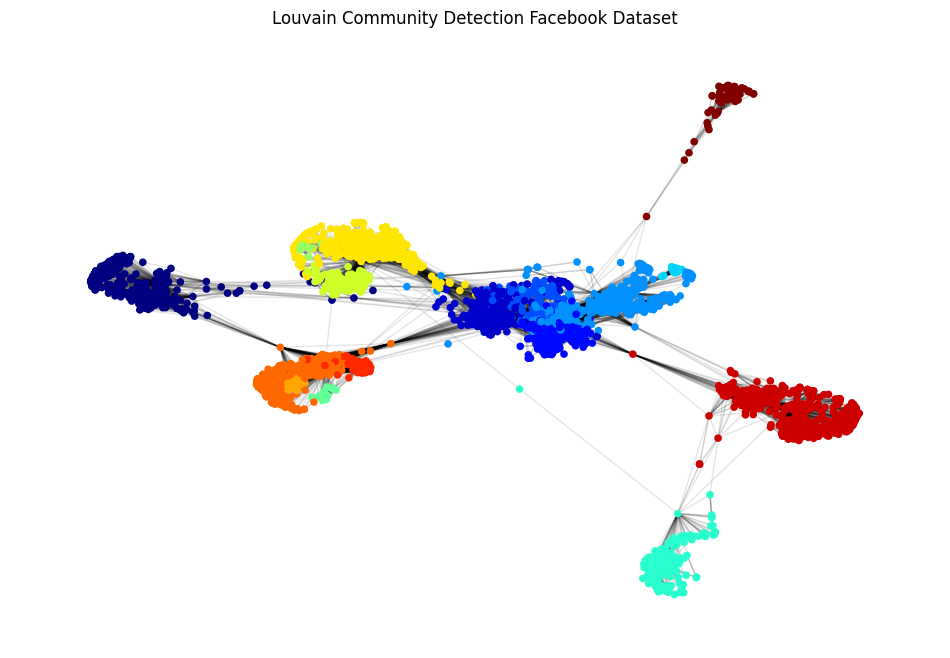

In [43]:
#plot nodes with colors based on community
community_map = {}

for i, community in enumerate(C):
    for node in community:
        community_map[node] = i
node_colors = [community_map[node] for node in G.nodes()]


plt.figure(figsize=(12, 8))
nx.draw_networkx_nodes (G, pos, node_size=20, node_color=node_colors, cmap=plt.cm.jet)
nx.draw_networkx_edges(G, pos, alpha=0.1)
plt.title("Louvain Community Detection Facebook Dataset")
plt.axis("off")
plt.show()

In [44]:
degree_dict = dict(G.degree())

In [45]:
top_nodes_per_community = {}

for i, community in enumerate(C):
    sorted_nodes = sorted(
        community,
        key=lambda node: degree_dict[node],
        reverse=True
    )
    
    top_nodes_per_community[i] = sorted_nodes[:5]

In [46]:
for comm_id, nodes in top_nodes_per_community.items():
    print(f"Community {comm_id}:")
    for node in nodes:
        print(f"  Node {node}, degree = {degree_dict[node]}")
    print()

Community 0:
  Node 0, degree = 347
  Node 56, degree = 78
  Node 67, degree = 76
  Node 271, degree = 73
  Node 322, degree = 72

Community 1:
  Node 107, degree = 1045
  Node 1888, degree = 254
  Node 1800, degree = 245
  Node 1663, degree = 235
  Node 1352, degree = 234

Community 2:
  Node 917, degree = 130
  Node 896, degree = 126
  Node 1277, degree = 124
  Node 1783, degree = 121
  Node 1104, degree = 109

Community 3:
  Node 1687, degree = 43
  Node 1548, degree = 38
  Node 1733, degree = 38
  Node 1787, degree = 38
  Node 1837, degree = 38

Community 4:
  Node 483, degree = 231
  Node 348, degree = 229
  Node 414, degree = 159
  Node 376, degree = 133
  Node 475, degree = 122

Community 5:
  Node 583, degree = 25
  Node 578, degree = 24
  Node 643, degree = 24
  Node 658, degree = 24
  Node 659, degree = 24

Community 6:
  Node 686, degree = 170
  Node 828, degree = 79
  Node 713, degree = 71
  Node 705, degree = 69
  Node 698, degree = 68

Community 7:
  Node 1988, degree = 2

In [55]:
with open("..//facebook_combined//node_to_features.txt", "r") as f:
    node_to_feature = {}
    for line in f:
        node, feature = line.strip().split(";")
        feature = feature.split(",")
        feature = [int(f) for f in feature]
        node_to_feature[int(node)] = feature

In [57]:
print(len(node_to_feature))
print(len(node_to_feature[0]))

4039
1283


In [ ]:
with open("..//facebook_combined//features_to_type.txt", "r") as f:

In [59]:
#find common features between the top 5 nodes in each community
for comm_id, nodes in top_nodes_per_community.items():
    sum_feature_list = [0]*(len(node_to_feature[0]))
    for node in nodes:
        sum_feature_list = [sum_feature_list[i] + node_to_feature[node][i] for i in range(len(node_to_feature[0]))]
    #print(max(sum_feature_list))
    print(sum_feature_list.index(max(sum_feature_list)))




127
53
53
127
52
278
53
53
52
53
127
78
53
53
127
78
